# Spacy

Installing SciSpacy and Spacy too

In [2]:
! pip install scispacy
! pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_md-0.5.4.tar.gz
! pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl --no-dependencies
! pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_bc5cdr_md-0.5.4.tar.gz
! pip install gensim
!pip install medspacy
import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
import re

from gensim.models import word2vec

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
%matplotlib inline

  Using cached https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_md-0.5.4.tar.gz (119.1 MB)
  Preparing metadata (setup.py) ... done
  Using cached spacy-3.7.5-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (27 kB)
  Using cached thinc-8.2.5-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (15 kB)
  Using cached blis-0.7.11-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.4 kB)
Using cached spacy-3.7.5-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (6.5 MB)
Using cached thinc-8.2.5-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (865 kB)
Using cached blis-0.7.11-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (10.2 MB)
  Attempting uninstall: blis
    Found existing installation: blis 1.3.3
    Uninstalling blis-1.3.3:
      Successfully uninstalled blis-1.3.3
  Attempting uninstall: thinc
    Found existing installation: thinc 8.3.10
    Uninstalling thinc-8.3.1

In [3]:
LENGTH_OF_DOC = 50

In [3]:
# load respiratory notes
from google.colab import files
uploaded = files.upload()


Saving df_430_respiratory_notes.csv to df_430_respiratory_notes (1).csv


In [4]:
import pandas as pd

PATH_NOTES = 'df_430_respiratory_notes.csv'

df_notes = pd.read_csv(PATH_NOTES, dtype={'SEQ_NUM': 'Int64'})

#notes = []
#with open('df_430_respiratory_notes (1).csv', 'r') as fin:
#  lines = fin.readlines()
#  for line in lines:
#    notes.append(line)
df_notes.iloc[0]['TEXT']
#print(len(notes))

'Demographics\n   Day of intubation: [**2110-10-10**]\n   Day of mechanical ventilation: 1\n   Ideal body weight: 47.6 None\n   Ideal tidal volume: 190.4 / 285.6 / 380.8 mL/kg\n   Airway\n   Airway Placement Data\n   Known difficult intubation: No\n   Procedure location: ICU\n   Reason: Elective\n   Tube Type\n   ETT:\n                   Position: 19 cm at teeth\n                   Route: Oral\n                   Type: Standard\n                   Size: 7.5mm\n   Lung sounds\n   RLL Lung Sounds: Diminished\n   RUL Lung Sounds: Clear\n   LUL Lung Sounds: Clear\n   LLL Lung Sounds: Diminished\n   Secretions\n   Sputum color / consistency: Yellow / Thick\n   Sputum source/amount: Suctioned / Moderate\n   Ventilation Assessment\n   Level of breathing assistance: Continuous invasive ventilation\n   Plan\n   Comments: Pt intubated electively for airway protection. Pt intubated\n   without incident. ETCO2 had a positive color change. BS are clear and\n   equal. ABG\ns reveal a respiratory alk

In [5]:
# notes_respiratory
import spacy
nlp = spacy.load('en_core_web_sm')
doc = []
for i in range(LENGTH_OF_DOC):
  doc.append(nlp(df_notes.iloc[i]['TEXT']))
  print(doc[-1])
  print('*************************************************************************************************************')

Demographics
   Day of intubation: [**2110-10-10**]
   Day of mechanical ventilation: 1
   Ideal body weight: 47.6 None
   Ideal tidal volume: 190.4 / 285.6 / 380.8 mL/kg
   Airway
   Airway Placement Data
   Known difficult intubation: No
   Procedure location: ICU
   Reason: Elective
   Tube Type
   ETT:
                   Position: 19 cm at teeth
                   Route: Oral
                   Type: Standard
                   Size: 7.5mm
   Lung sounds
   RLL Lung Sounds: Diminished
   RUL Lung Sounds: Clear
   LUL Lung Sounds: Clear
   LLL Lung Sounds: Diminished
   Secretions
   Sputum color / consistency: Yellow / Thick
   Sputum source/amount: Suctioned / Moderate
   Ventilation Assessment
   Level of breathing assistance: Continuous invasive ventilation
   Plan
   Comments: Pt intubated electively for airway protection. Pt intubated
   without incident. ETCO2 had a positive color change. BS are clear and
   equal. ABG
s reveal a respiratory alkalosis with good oxygenation. P

In [6]:
# Name Entities - SPACY

doc = []
for i in range(LENGTH_OF_DOC):
  doc.append(nlp(df_notes.iloc[i]['TEXT']))
  for ent in doc[-1].ents:
    print(ent.text, ent.start_char, ent.end_char, ent.label_)
  print("*********************************************************")

2110-10-10 38 48 DATE
1 86 87 CARDINAL
Ideal 91 96 ORG
47.6 110 114 CARDINAL
Ideal 123 128 ORG
190.4 / 285.6 143 156 CARDINAL
Airway 174 180 GPE
ICU 263 266 ORG
ETT 303 306 PRODUCT
19 cm 337 342 QUANTITY
Size 436 440 PERSON
7.5 442 445 CARDINAL
mm
   Lung 445 455 PERSON
LUL Lung Sounds: Clear 523 545 PRODUCT
LLL Lung Sounds 549 564 PERSON
Yellow / Thick 622 636 ORG
Sputum 640 646 PERSON
Suctioned / Moderate
   Ventilation Assessment
   Level 662 717 ORG
Plan
   Comments 778 794 WORK_OF_ART
ETCO2 877 882 ORG
AC 1017 1019 ORG
ABG 1040 1043 ORG
*********************************************************
2110-10-10 38 48 DATE
3 86 87 CARDINAL
Ideal 91 96 ORG
47.6 110 114 CARDINAL
Ideal 123 128 ORG
190.4 / 285.6 143 156 CARDINAL
Airway 174 180 GPE
ICU 263 266 ORG
Tube Type
   ETT 270 286 ORG
19 cm 317 322 QUANTITY
Size 416 420 PERSON
7.5 422 425 CARDINAL
Cuff  Management:
                   Vol/Press 431 477 ORG
Cuff 514 518 PERSON
25 529 531 CARDINAL
Cuff 574 578 PERSON
8  mL 587 592 CARDINA

In [7]:
# Entity Visualizer
from spacy import displacy
for i in range(LENGTH_OF_DOC):
  displacy.render(doc[i], style="ent", jupyter=True)
  print('*********************************************************************************************************************************************************************')

*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


...

*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


In [8]:
# Build corpus of all the entities extracted from the notes using spaCy model.
# The corpus is an array of arrays or list of lists where each of the nested lists corresponds to a note.
corpus=[]
for row in range(LENGTH_OF_DOC):
  str_tokens=[]
  tokens= nlp(df_notes.iloc[row]['TEXT']).ents
  for i in range(0, len(tokens)):
    str_tokens.append(tokens[i].text)
  corpus.append(list(str_tokens))


print(corpus)

[['2110-10-10', '1', 'Ideal', '47.6', 'Ideal', '190.4 / 285.6', 'Airway', 'ICU', 'ETT', '19 cm', 'Size', '7.5', 'mm\n   Lung', 'LUL Lung Sounds: Clear', 'LLL Lung Sounds', 'Yellow / Thick', 'Sputum', 'Suctioned / Moderate\n   Ventilation Assessment\n   Level', 'Plan\n   Comments', 'ETCO2', 'AC', 'ABG'], ['2110-10-10', '3', 'Ideal', '47.6', 'Ideal', '190.4 / 285.6', 'Airway', 'ICU', 'Tube Type\n   ETT', '19 cm', 'Size', '7.5', 'Cuff  Management:\n                   Vol/Press', 'Cuff', '25', 'Cuff', '8  mL', 'LUL Lung Sounds: Clear', 'LLL Lung Sounds', 'Sputum', 'Suctioned / Small\n   Comments', 'Ventilation Assessment\n   Plan', '24-48 hours', 'daily', 'SBT', '101.7'], ['2110-10-10', '3', 'Ideal', '47.6', 'Ideal', '190.4 / 285.6', 'Airway', 'Tube Type\n   ETT', '19 cm', 'Size', '7.5', 'mm\n   Lung', 'LUL Lung Sounds: Clear', 'LLL Lung Sounds', 'Sputum', 'Suctioned / Small\n   Ventilation Assessment\n   Level', 'Plan', '24-48 hours', 'daily', 'SBT', 'AC', 'LUL', '5/5', '470'], ['0', 'Ide

In [9]:
#create embeddings
from gensim.models import Word2Vec
model1 = Word2Vec(corpus, min_count=1)

In [10]:
model1.wv['Airway']

array([-1.0022426e-02,  1.0954227e-02,  4.3881857e-03,  9.7855814e-03,
        7.1130828e-03,  1.0039172e-04,  1.2169639e-02, -5.8260665e-04,
       -8.7395739e-03,  1.8273263e-03,  4.6205143e-03, -8.4807267e-03,
        1.0367019e-02, -2.2946759e-03,  1.0692942e-02,  6.1700272e-04,
       -4.9642553e-03, -2.4397864e-03, -8.4534064e-03, -8.1949923e-03,
        1.4728822e-03,  1.0803917e-02,  1.1041206e-02, -8.4299520e-03,
        2.9677907e-03,  2.9651017e-03, -3.7988524e-03, -9.8084481e-03,
       -6.3926069e-04, -7.4777966e-03,  7.7120950e-03, -6.2558823e-03,
        8.3230855e-03,  7.4586589e-03, -1.4669474e-03,  7.1082348e-03,
       -1.2256523e-03,  6.9673546e-03,  2.8210722e-03, -1.1026310e-02,
       -2.8882346e-03,  2.0886941e-03, -8.4952847e-04, -5.7639182e-04,
        5.0305721e-04, -2.7717690e-03, -2.2095698e-04,  2.5797214e-03,
       -3.2001280e-03, -2.1822066e-03,  8.1389264e-04, -8.7420939e-04,
       -7.2481914e-04, -5.6923041e-03,  4.7317576e-03, -2.3239790e-03,
      

In [11]:
model1.wv.similar_by_word('Airway')

[('Cuff', 0.41571804881095886),
 ('0', 0.3416338860988617),
 ('LUL Lung Sounds', 0.34149622917175293),
 ('MD', 0.2758607864379883),
 ('Manufacturer', 0.26716718077659607),
 ('Metavision', 0.2622877061367035),
 ('Tube Type\n   ETT', 0.25662973523139954),
 ('Ideal', 0.25154897570610046),
 ('Cont PSV', 0.24397891759872437),
 ('LUL Lung Sounds: Clear', 0.24305696785449982)]

In [12]:
# create TSNE
import numpy as np

def tsne_plot(model,words, preTrained=False):
    "Creates and TSNE model and plots it"
    labels = []
    tokens = []

    for word in words:
      if preTrained:
          tokens.append(model[word])
      else:
          tokens.append(model.wv[word])
      labels.append(word)

    tokens = np.array(tokens)
    tsne_model = TSNE(perplexity=LENGTH_OF_DOC, early_exaggeration=12, n_components=2, init='pca', n_iter=1000, random_state=23)
    new_values = tsne_model.fit_transform(tokens)

    x = []
    y = []
    for value in new_values:
        x.append(value[0])
        y.append(value[1])

    plt.figure(figsize=(16, 16))
    for i in range(len(x)):
        plt.scatter(x[i],y[i])
        plt.annotate(labels[i],
                     xy=(x[i], y[i]),
                     xytext=(5, 2),
                     textcoords='offset points',
                     ha='right',
                     va='bottom')
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


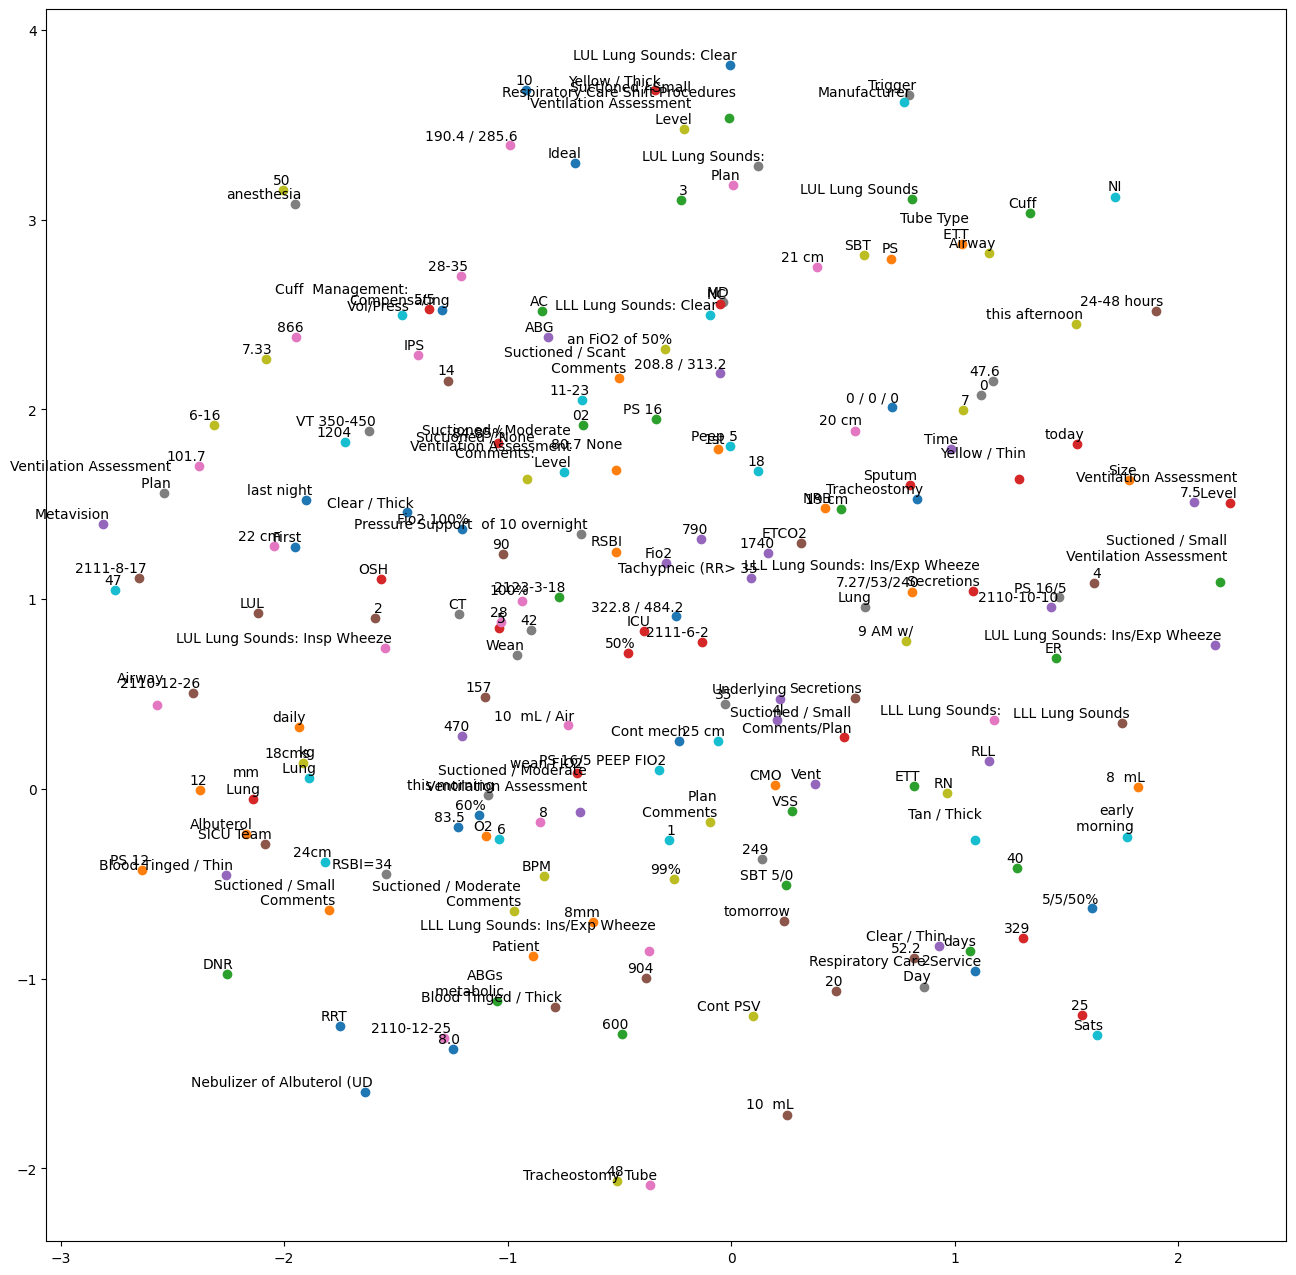

In [13]:
vocabs = model1.wv.key_to_index.keys()
new_v = np.array(list(vocabs))
tsne_plot(model1,new_v)

# SciSpacy

scispaCy is a Python package containing spaCy models for processing biomedical, scientific or clinical text.



See https://allenai.github.io/scispacy/ for more details.

In [14]:

import en_ner_bc5cdr_md
nlp = en_ner_bc5cdr_md.load()
doc = []
for i in range(LENGTH_OF_DOC):
  doc.append(nlp(df_notes.iloc[i]['TEXT']))
  for ent in doc[-1].ents:
    print(ent.text, ent.start_char, ent.end_char, ent.label_)
  print("*********************************************************")

/usr/local/lib/python3.12/dist-packages/spacy/util.py:969: UserWarning: [W095] Model 'en_ner_bc5cdr_md' (0.5.4) was trained with spaCy v3.7.4 and may not be 100% compatible with the current version (3.8.11). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/spacy/language.py:2231: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


LLL 549 552 CHEMICAL
Pt 843 845 CHEMICAL
respiratory alkalosis 954 975 DISEASE
PSV 1023 1026 CHEMICAL
PSV 1083 1086 CHEMICAL
*********************************************************
cmH2O 533 538 CHEMICAL
LLL 712 715 CHEMICAL
Pt 1070 1072 CHEMICAL
*********************************************************
Wheeze 474 480 DISEASE
Rhonchi 501 508 DISEASE
LLL 538 541 CHEMICAL
Wheeze 559 565 DISEASE
rhonchi 984 991 DISEASE
expiratory wheezes 1039 1057 DISEASE
*********************************************************
Wheeze 267 273 DISEASE
Wheeze 302 308 DISEASE
Wheeze 337 343 DISEASE
LLL 347 350 CHEMICAL
Wheeze 372 378 DISEASE
Pt 713 715 CHEMICAL
Albuterol 842 851 CHEMICAL
*********************************************************
expiratory wheeze 122 139 DISEASE
Albuterol 198 207 CHEMICAL
*********************************************************
*********************************************************
cmH2O
                                    661 702 CHEMICAL
LLL 894 897 CHEMICAL
Pt 1467 

In [15]:
# Entity Visualizer
from spacy import displacy
for i in range(LENGTH_OF_DOC):
  displacy.render(doc[i], style="ent", jupyter=True)
  print('*********************************************************************************************************************************************************************')

*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


...

*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


In [16]:
# Build corpus of all the entities extracted from the notes using spaCy model.
# The corpus is an array of arrays or list of lists where each of the nested lists corresponds to a note.
corpus=[]
for row in range(LENGTH_OF_DOC):
  str_tokens=[]
  tokens= nlp(df_notes.iloc[row]['TEXT']).ents
  for i in range(0, len(tokens)):
    str_tokens.append(tokens[i].text)
  corpus.append(list(str_tokens))


print(corpus)

[['LLL', 'Pt', 'respiratory alkalosis', 'PSV', 'PSV'], ['cmH2O', 'LLL', 'Pt'], ['Wheeze', 'Rhonchi', 'LLL', 'Wheeze', 'rhonchi', 'expiratory wheezes'], ['Wheeze', 'Wheeze', 'Wheeze', 'LLL', 'Wheeze', 'Pt', 'Albuterol'], ['expiratory wheeze', 'Albuterol'], [], ['cmH2O\n                                   ', 'LLL', 'Pt', 'DNR', 'CMO'], [], ['LLL', 'ICH'], ['cmH2O', 'LLL', 'Pt'], ['Rhonchi', 'LLL', 'Rhonchi', 'PSV'], ['cmH2O', 'Wheeze', 'Wheeze', 'LLL', 'PEEP', 'FiO2'], ['cmH2O\n                                   ', 'Wheeze', 'Wheeze', 'LLL', 'Wheeze'], ['cmH2O\n                                   ', 'LLL', 'dyspnea'], ['LLL', 'dyspnea'], ['LLL', 'dyspnea'], ['metabolic acidosis'], ['LLL', 'dyspnea'], ['Combivent'], ['Wheeze', 'Wheeze', 'LLL', 'MDIs', 'dyspnea'], ['Rhonchi', 'LLL', 'Rhonchi', 'dyspnea', 'PEEP', 'PEEP'], ['Rhonchi', 'Rhonchi', 'LLL', 'Pt', 'tachypneic', 'anxiety', 'dyspnea'], ['cmH2O\n                                   ', 'Rhonchi', 'Rhonchi', 'LLL', 'NRB', 'VSS', 'O2 sats']

In [17]:
#create embeddings
from gensim.models import Word2Vec
model2 = Word2Vec(corpus, min_count=1)

In [18]:
model2.wv['Wheeze']

array([-8.2798693e-03,  9.3225455e-03, -2.3714072e-04, -1.9171694e-03,
        4.6335110e-03, -4.1583651e-03,  2.7966055e-03,  7.0121032e-03,
        6.0783238e-03, -7.5621535e-03,  9.4745839e-03,  4.6281819e-03,
        3.9835768e-03, -6.1925743e-03,  8.4673828e-03, -2.1736668e-03,
        8.9204749e-03, -5.3956117e-03, -8.1708618e-03,  6.8037757e-03,
        1.7247805e-03, -2.1604365e-03,  9.6027330e-03,  9.5644314e-03,
       -9.7811995e-03,  2.4926465e-03,  6.1256588e-03,  3.8736621e-03,
        1.9945968e-03,  3.7798437e-04,  7.5316028e-04, -3.8266219e-03,
       -7.1399626e-03, -2.1120708e-03,  3.8750567e-03,  8.8633653e-03,
        9.2854481e-03, -5.9939069e-03, -9.4334735e-03,  9.7404635e-03,
        3.4501597e-03,  5.1684864e-03,  6.3085021e-03, -2.8776228e-03,
        7.3595135e-03,  2.8921987e-03,  2.8041564e-03, -2.3906780e-03,
       -3.1103140e-03, -2.3497450e-03,  4.2596059e-03,  3.1783256e-05,
       -9.6516265e-03, -9.7028762e-03, -6.1369156e-03, -1.7994108e-04,
      

In [19]:
model2.wv.similar_by_word('Wheeze')

[('metabolic acidosis', 0.17882505059242249),
 ('PSV', 0.13397283852100372),
 ('Pt', 0.0797855481505394),
 ('rhonchi', 0.0708829015493393),
 ('Rhonchi', 0.06862889230251312),
 ('VSS', 0.04856035113334656),
 ('PEEP', 0.04823264852166176),
 ('ICH', 0.04790852591395378),
 ('hypoxemia', 0.04240858554840088),
 ('acidosis', 0.0421840138733387)]

In [22]:
# create TSNE
import numpy as np

def tsne_plot(model,words, preTrained=False):
    "Creates and TSNE model and plots it"
    labels = []
    tokens = []

    for word in words:
      if preTrained:
          tokens.append(model[word])
      else:
          tokens.append(model.wv[word])
      labels.append(word)

    tokens = np.array(tokens)
    tsne_model = TSNE(perplexity=12, early_exaggeration=12, n_components=2, init='pca', n_iter=1000, random_state=23)
    new_values = tsne_model.fit_transform(tokens)

    x = []
    y = []
    for value in new_values:
        x.append(value[0])
        y.append(value[1])

    plt.figure(figsize=(16, 16))
    for i in range(len(x)):
        plt.scatter(x[i],y[i])
        plt.annotate(labels[i],
                     xy=(x[i], y[i]),
                     xytext=(5, 2),
                     textcoords='offset points',
                     ha='right',
                     va='bottom')
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


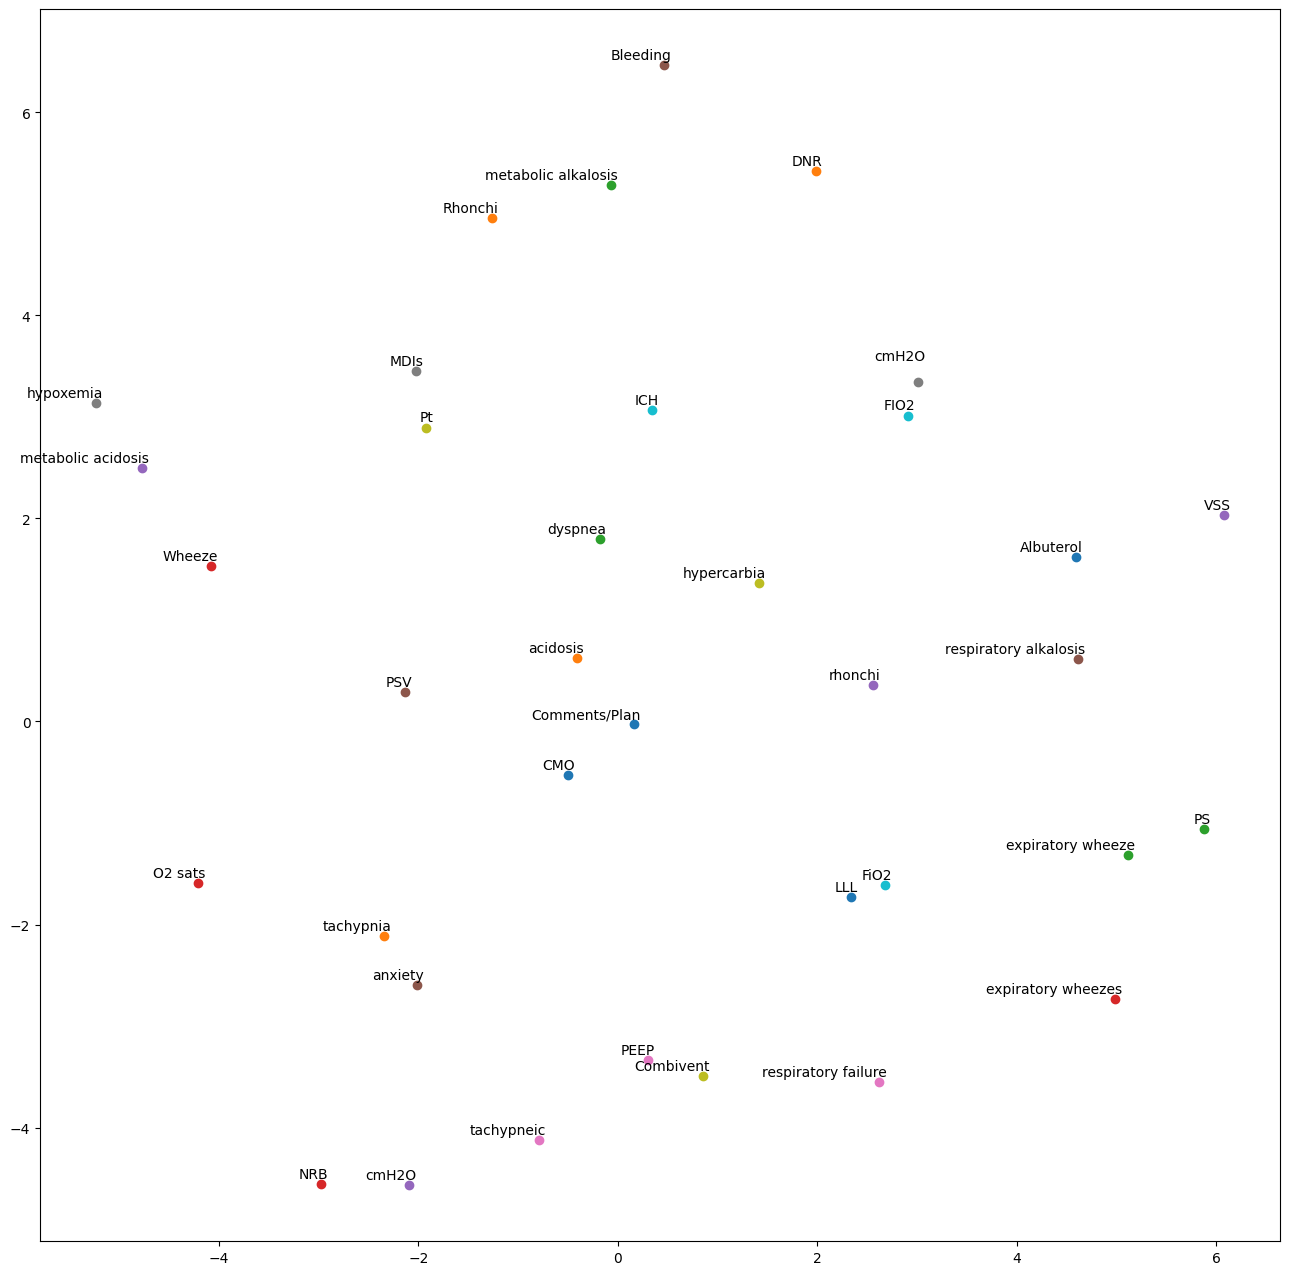

In [23]:
vocabs = model2.wv.key_to_index.keys()
new_v = np.array(list(vocabs))
tsne_plot(model2,new_v)

# MedSPacy



In [5]:
import medspacy
from medspacy.ner import TargetRule
from medspacy.visualization import visualize_ent
nlp = medspacy.load(medspacy_enable=['medspacy_pyrush', 'medspacy_target_matcher', 'medspacy_context', 'medspacy_sectionizer'])

# Get the existing rule-based entity recognizer from the pipeline
ruler = nlp.get_pipe("medspacy_target_matcher")

# Define some target rules to extract medical entities
rules = [
    TargetRule("respiratory alkalosis", "DISEASE"),
    TargetRule("Wheeze", "DISEASE"),
    TargetRule("Albuterol", "CHEMICAL"),
    TargetRule("PSV", "CHEMICAL"),
    TargetRule("cmH2O", "CHEMICAL"),
    TargetRule("Rhonchi", "DISEASE"),
    TargetRule("ICH", "DISEASE"),
    TargetRule("LLL", "ANATOMY"), # Added LLL as it appeared frequently
    TargetRule("Pt", "PERSON"),   # Added Pt as it appeared frequently
]

ruler.add(rules)

doc = []
for i in range(LENGTH_OF_DOC):
  doc.append(nlp(df_notes.iloc[i]['TEXT']))


2026-03-01 01:17:40.811 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=0] [doc 0] Token 0 'Demographics' marked as sentence start (span begin)
2026-03-01 01:17:40.812 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=0] [doc 0] Token 17 '
   ' marked as sentence start (span end whitespace)
2026-03-01 01:17:40.813 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=0] [doc 0] GAP DETECTED: tokens 17-17 (idx 51-51) between spans 51-55
2026-03-01 01:17:40.813 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=0] [doc 0] Token 17 '
   ' marked as sentence start (whitespace in gap between spans)
2026-03-01 01:17:40.814 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=0] [doc 0] Token 18 'Day' marked as sentence start (span begin)
2026-03-01 01:17:40.814 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=0] [

LLL 549 552 ANATOMY
Pt 796 798 PERSON
Pt 843 845 PERSON
respiratory alkalosis 954 975 DISEASE
Pt 999 1001 PERSON
PSV 1023 1026 CHEMICAL
PSV 1083 1086 CHEMICAL
*********************************************************
cmH2O 533 538 CHEMICAL
LLL 712 715 ANATOMY
Pt 1070 1072 PERSON
Pt 1114 1116 PERSON
psv 1130 1133 CHEMICAL
*********************************************************
Wheeze 474 480 DISEASE
Rhonchi 501 508 DISEASE
LLL 538 541 ANATOMY
Wheeze 559 565 DISEASE
Pt 935 937 PERSON
rhonchi 984 991 DISEASE
Pt 1080 1082 PERSON
Pt 1172 1174 PERSON
PSV 1185 1188 CHEMICAL
Pt 1194 1196 PERSON
*********************************************************
Wheeze 267 273 DISEASE
Wheeze 302 308 DISEASE
Wheeze 337 343 DISEASE
LLL 347 350 ANATOMY
Wheeze 372 378 DISEASE
Pt 500 502 PERSON
PSV 515 518 CHEMICAL
Pt 564 566 PERSON
Pt 634 636 PERSON
Pt 713 715 PERSON
Pt 747 749 PERSON
Albuterol 842 851 CHEMICAL
*********************************************************
Pt 31 33 PERSON
wheeze 133 139 DISEASE

2026-03-01 01:17:41.051 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=5] [doc 0] Token 2 '
   ' marked as sentence start (span end whitespace)
2026-03-01 01:17:41.052 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=5] [doc 0] GAP DETECTED: tokens 2-2 (idx 6-6) between spans 6-10
2026-03-01 01:17:41.052 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=5] [doc 0] Token 2 '
   ' marked as sentence start (whitespace in gap between spans)
2026-03-01 01:17:41.054 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=5] [doc 0] Token 3 'Respiratory' marked as sentence start (span begin)
2026-03-01 01:17:41.055 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=5] [doc 0] Token 17 'BS' marked as sentence start (span end next token)
2026-03-01 01:17:41.055 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=5] [

pt 35 37 PERSON
Pt 169 171 PERSON
*********************************************************
cmH2O 661 666 CHEMICAL
LLL 894 897 ANATOMY
Pt 1467 1469 PERSON
*********************************************************
Pt 31 33 PERSON
psv 43 46 CHEMICAL
*********************************************************


2026-03-01 01:17:41.297 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=8] [doc 0] Token 228 'Comfort' marked as sentence start (span begin)
2026-03-01 01:17:41.298 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=8] [doc 0] Token 231 '
' marked as sentence start (span end whitespace)
2026-03-01 01:17:41.299 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=8] [doc 0] Token 231 '
' marked as sentence start (whitespace after all spans)
2026-03-01 01:17:41.301 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=8] Token/tag mapping: [(Demographics, True), (
   , False), (Day, False), (of, False), (intubation, False), (:, False), (
   , True), (Day, True), (of, False), (mechanical, False), (ventilation, False), (:, False), (
   , True), (Ideal, True), (body, False), (weight, False), (:, False), (
   , True), (Ideal, True), (tidal, False), (volume, False), (:, False)

...

cmH2O 489 494 CHEMICAL
LLL 628 631 ANATOMY
pt 935 937 PERSON
*********************************************************
cmH2O 652 657 CHEMICAL
LLL 884 887 ANATOMY
*********************************************************
Rhonchi 227 234 DISEASE
Rhonchi 255 262 DISEASE
LLL 266 269 ANATOMY
Pt 556 558 PERSON
*********************************************************


2026-03-01 01:17:43.905 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=44] [doc 0] GAP DETECTED: tokens 199-199 (idx 1150-1150) between spans 1150-1154
2026-03-01 01:17:43.906 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=44] [doc 0] Token 199 '
   ' marked as sentence start (whitespace in gap between spans)
2026-03-01 01:17:43.907 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=44] [doc 0] Token 200 'Non' marked as sentence start (span begin)
2026-03-01 01:17:43.907 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=44] [doc 0] Token 206 '
   ' marked as sentence start (span end whitespace)
2026-03-01 01:17:43.908 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=44] [doc 0] GAP DETECTED: tokens 206-206 (idx 1190-1190) between spans 1190-1194
2026-03-01 01:17:43.908 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredi

cmH2O 628 633 CHEMICAL
LLL 855 858 ANATOMY
pt 1582 1584 PERSON
Pt 1644 1646 PERSON
PSV 1709 1712 CHEMICAL
*********************************************************
cmH2O 505 510 CHEMICAL
Rhonchi 577 584 DISEASE
Rhonchi 605 612 DISEASE
LLL 616 619 ANATOMY
Rhonchi 633 640 DISEASE
Pt 913 915 PERSON
PSV 928 931 CHEMICAL
*********************************************************
cmH2O 523 528 CHEMICAL
Rhonchi 715 722 DISEASE
Rhonchi 743 750 DISEASE
LLL 754 757 ANATOMY
*********************************************************


2026-03-01 01:17:44.157 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=47] [doc 0] Token 0 'Demographics' marked as sentence start (span begin)
2026-03-01 01:17:44.158 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=47] [doc 0] Token 17 '
   ' marked as sentence start (span end whitespace)
2026-03-01 01:17:44.159 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=47] [doc 0] GAP DETECTED: tokens 17-17 (idx 50-50) between spans 50-54
2026-03-01 01:17:44.161 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=47] [doc 0] Token 17 '
   ' marked as sentence start (whitespace in gap between spans)
2026-03-01 01:17:44.161 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=47] [doc 0] Token 18 'Day' marked as sentence start (span begin)
2026-03-01 01:17:44.162 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id

LLL 418 421 ANATOMY
Pt 718 720 PERSON
pt 782 784 PERSON
Pt 840 842 PERSON
Pt 879 881 PERSON
Albuterol 888 897 CHEMICAL
pt 934 936 PERSON
Pt 1033 1035 PERSON
Pt 1114 1116 PERSON
*********************************************************
cmH2O 508 513 CHEMICAL
LLL 735 738 ANATOMY
*********************************************************
cmH2O 652 657 CHEMICAL
LLL 899 902 ANATOMY
*********************************************************


In [6]:
# Entity Visualizer
#from spacy import displacy
#for i in range(LENGTH_OF_DOC):
#  displacy.render(doc[i], style="ent", jupyter=True)
#  print('*********************************************************************************************************************************************************************')

for note in doc:
  visualize_ent(note)

*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


...

*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


*********************************************************************************************************************************************************************


In [ ]:
# Build corpus of all the entities extracted from the notes using MEDspaCy model.
# The corpus is an array of arrays or list of lists where each of the nested lists corresponds to a note.
corpus=[]
for row in range(LENGTH_OF_DOC):
  str_tokens=[]
  tokens= nlp(df_notes.iloc[row]['TEXT']).ents
  for i in range(0, len(tokens)):
    str_tokens.append(tokens[i].text)
  corpus.append(list(str_tokens))


print(corpus)

In [ ]:
#create embeddings
from gensim.models import Word2Vec
model3 = Word2Vec(corpus, min_count=1)

In [19]:
model3.wv['Wheeze']

array([ 1.1936937e-04,  3.0933302e-03, -6.8074944e-03, -1.3750404e-03,
        7.6689869e-03,  7.3329490e-03, -3.6818364e-03,  2.6609693e-03,
       -8.3344569e-03,  6.1944909e-03, -4.6234978e-03, -3.1642593e-03,
        9.3212929e-03,  8.6417247e-04,  7.5102416e-03, -6.0843634e-03,
        5.1597287e-03,  9.9142874e-03, -8.4682098e-03, -5.1624398e-03,
       -7.0801745e-03, -4.8841042e-03, -3.7718907e-03, -8.5609294e-03,
        7.9360111e-03, -4.8586838e-03,  8.4156627e-03,  5.2753538e-03,
       -6.5409089e-03,  3.9644442e-03,  5.4645473e-03, -7.4445847e-03,
       -7.4013029e-03, -2.4690046e-03, -8.6251656e-03, -1.5768381e-03,
       -4.0009595e-04,  3.3000049e-03,  1.4220109e-03, -8.9335558e-04,
       -5.6148227e-03,  1.7284642e-03, -9.0000784e-04,  6.8185525e-03,
        3.9665592e-03,  4.5215338e-03,  1.4507393e-03, -2.7027358e-03,
       -4.3808375e-03, -1.0158155e-03,  1.4383235e-03, -2.6589127e-03,
       -7.0722429e-03, -7.7999420e-03, -9.1379881e-03, -5.9395293e-03,
      

In [9]:
model3.wv.similar_by_word('Wheeze')

[('wheeze', 0.16738569736480713),
 ('PSV', 0.14004969596862793),
 ('Rhonchi', 0.13185976445674896),
 ('cmH2O', 0.06863170862197876),
 ('Albuterol', 0.061115991324186325),
 ('ICH', 0.019667144864797592),
 ('pt', 0.01965879276394844),
 ('LLL', 0.011655415408313274),
 ('rhonchi', -0.05638645589351654),
 ('Pt', -0.05740020051598549)]

In [14]:
# create TSNE
import numpy as np

def tsne_plot(model,words, preTrained=False):
    "Creates and TSNE model and plots it"
    labels = []
    tokens = []

    for word in words:
      if preTrained:
          tokens.append(model[word])
      else:
          tokens.append(model.wv[word])
      labels.append(word)

    tokens = np.array(tokens)
    tsne_model = TSNE(perplexity=10, early_exaggeration=12, n_components=2, init='pca', n_iter=1000, random_state=23)
    new_values = tsne_model.fit_transform(tokens)

    x = []
    y = []
    for value in new_values:
        x.append(value[0])
        y.append(value[1])

    plt.figure(figsize=(16, 16))
    for i in range(len(x)):
        plt.scatter(x[i],y[i])
        plt.annotate(labels[i],
                     xy=(x[i], y[i]),
                     xytext=(5, 2),
                     textcoords='offset points',
                     ha='right',
                     va='bottom')
    plt.show()

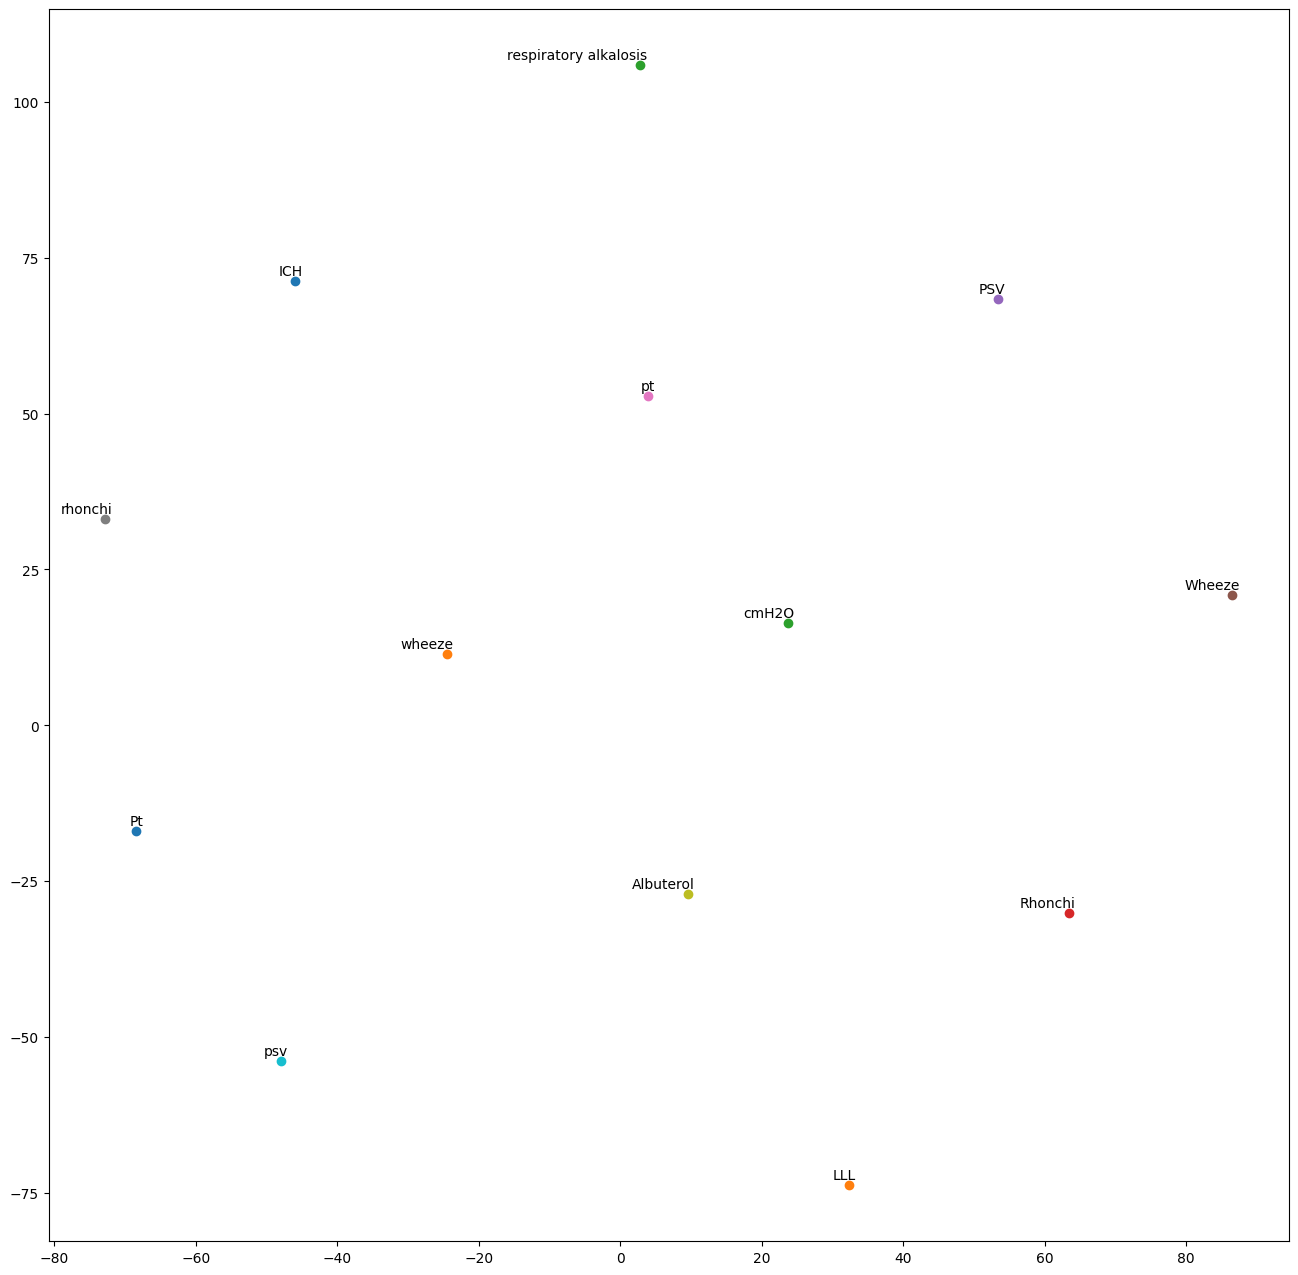

In [15]:
vocabs = model3.wv.key_to_index.keys()
new_v = np.array(list(vocabs))
tsne_plot(model3,new_v)